# Random Forest Regression
A random forest is an ensemble learning method that combines the predictions from multiple decision trees to produce a more accurate and stable prediction. 

It is a type of supervised learning algorithm that can be used for both classification and regression tasks.

In regression task we can use Random Forest Regression technique for predicting numerical values. It predicts continuous values by averaging the results of multiple decision trees.

Random Forest Regression works by creating multiple of decision trees each trained on a random subset of the data.

The process begins with Bootstrap sampling where random rows of data are selected with replacement to form different training datasets for each tree.

After this we do feature sampling where only a random subset of features is used to build each tree ensuring diversity in the models.

After the trees are trained each tree make a prediction and the final prediction for regression tasks is the average of all the individual tree predictions and this process is called as Aggregation.

This approach is beneficial because individual decision trees may have high variance and are prone to overfitting especially with complex data.

However by averaging the predictions from multiple decision trees Random Forest minimizes this variance leading to more accurate and stable predictions and hence improving generalization of model.

# Implementing Random Forest Regression in Python
data in dataset - bike_rentals 


In [172]:
# necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# load

In [175]:
# import dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\bike_rentals.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


# explore

In [178]:
df.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [180]:
df.describe()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
std,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454
min,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000


In [182]:
#df.isnull().sum()

In [184]:
df.drop(["datetime"], axis=1, inplace=True)

Text(0, 0.5, 'frequency')

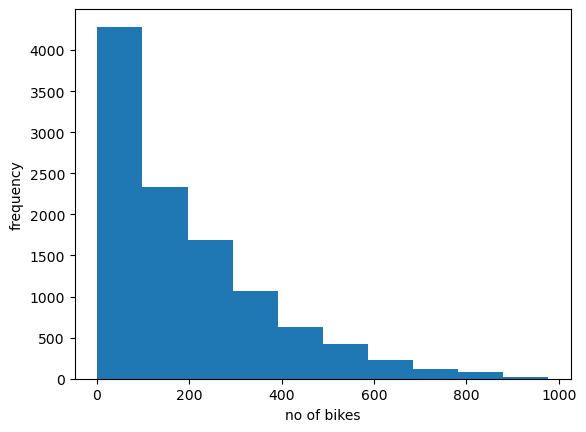

In [186]:
plt.hist(df['count'])
plt.xlabel('no of bikes')
plt.ylabel('frequency')

# split

In [189]:
X = df.iloc[:, :-1] # all rows ,  all cols except the last col
y = df.iloc[:, -1] # all rows ,  the last col

# train

In [192]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42)
print(X_train.shape)
print(y_train.shape)

(8164, 10)
(8164,)


# baseline

In [195]:
y_pred_baseline = [y_train.mean()] * len(y_train)
print(y_pred_baseline[:5])

[191.33978441940226, 191.33978441940226, 191.33978441940226, 191.33978441940226, 191.33978441940226]


# predict 

In [198]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()

model = rf.fit(X_train,y_train)

y_pred = model.predict(X_test)
print(y_pred)

[127.36  12.98 161.97 ...  26.02 126.65  82.57]


# evaluate

In [200]:
from sklearn.metrics import mean_squared_error

mae_baseline = mean_squared_error(y_train,y_pred_baseline)
print("mae_baseline:", mae_baseline)

mae = mean_squared_error(y_test,y_pred)
print("mae:", mae)

mae_baseline: 32808.831876288656
mae: 10.186936994856717


# example 2
data in dataset - Position_Salaries

In [411]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# load

In [364]:
# import dataset
df = pd.read_csv("C:\\Users\\franc\\Datascience_python\\dataset\\Position_Salaries.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 372.0+ bytes


In [366]:
df.head()

,Position,Level,Salary
0,Business Analyst,1,45000
1,Junior Consultant,2,50000
2,Senior Consultant,3,60000
3,Manager,4,80000
4,Country Manager,5,110000


# data preparation
Extracting Features: It extracts the features from the DataFrame and stores them in a variable named X.

Extracting Target Variable: It extracts the target variable from the DataFrame and stores it in a variable named y.

In [369]:
# Select feature (independent variable) and target (dependent variable)
X = df[['Level']].values  # 2D array for model compatibility
y = df['Salary'].values   # Target variable

# Random Forest Regressor Model
The code processes categorical data by encoding it numerically, combines the processed data with numerical data, and trains a Random Forest Regression model using the prepared data.

In [413]:
# Create and train the Random Forest Regressor
model = RandomForestRegressor(n_estimators=10, random_state=0,oob_score=True)
model.fit(X, y)

RandomForestRegressor(n_estimators=10, oob_score=True, random_state=0)

RandomForestRegressor: It builds multiple decision trees and combines their predictions.

n_estimators=100: Defines the number of decision trees in the Random Forest (10 trees in this case).

random_state=42: Ensures the randomness in model training is controlled for reproducibility.

# Make predictions

In [415]:
# Predict salary for existing levels
y_pred = model.predict(X)

# Predict salary for a new level (example: Level 6.5)
new_level = np.array([[6.5]])
predicted_salary = model.predict(new_level)
print(f"Predicted salary for Level 6.5: {predicted_salary[0]}")


Predicted salary for Level 6.5: 167000.0


#  Visualization

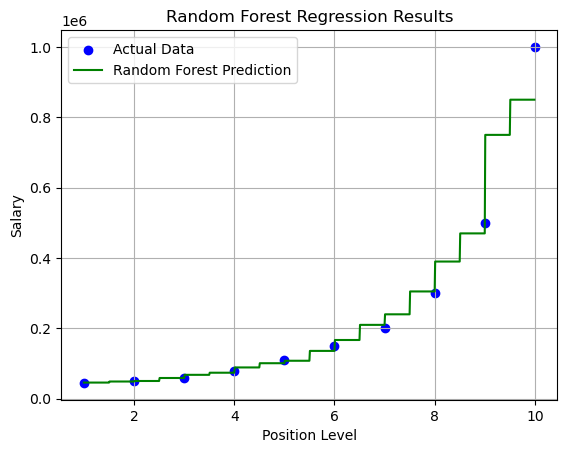

In [417]:
# Generate a smoother curve
X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)
y_grid_pred = model.predict(X_grid)

# Plot actual data points
plt.scatter(X, y, color='blue', label="Actual Data")

# Plot the Random Forest prediction curve
plt.plot(X_grid, y_grid_pred, color='green', label="Random Forest Prediction")

# Customize the plot
plt.title("Random Forest Regression Results")
plt.xlabel('Position Level')
plt.ylabel('Salary')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

#  Evaluate the Model Performance

In [421]:
oob_score = model.oob_score_
print(f'Out-of-Bag Score: {oob_score}')

# Calculate errors
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

r2 = r2_score(y, predictions)
print(f'R-squared: {r2}')

Out-of-Bag Score: 0.6819214296245728
Mean Absolute Error (MAE): 22700.0
Mean Squared Error (MSE): 2384100000.0
Root Mean Squared Error (RMSE): 48827.24649209701
R-squared: 0.9671801245316117


# Visualizing a Single Decision Tree from the Random Forest Model

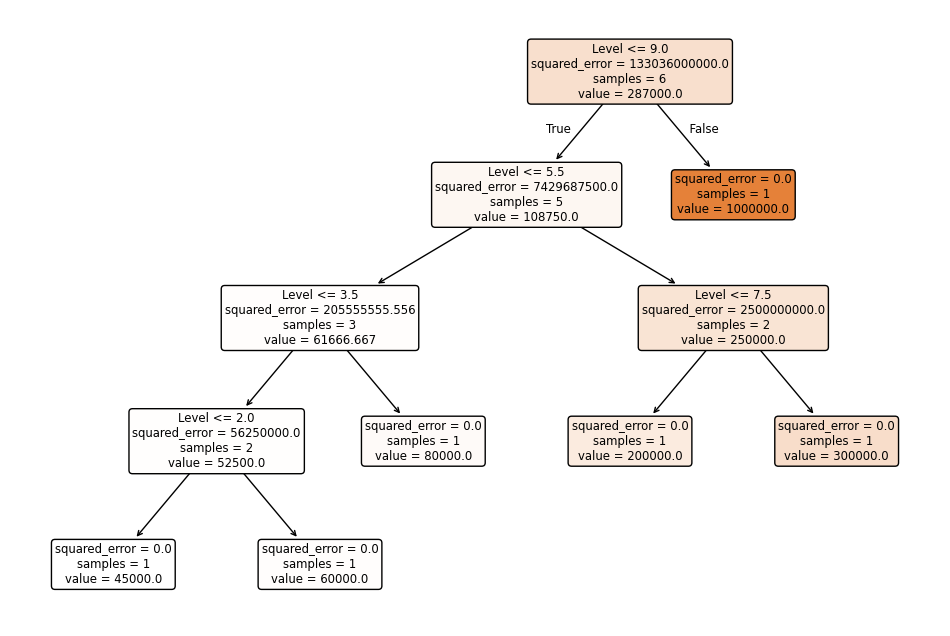

In [423]:
from sklearn.tree import export_text, plot_tree
# Select one tree from the trained Random Forest model
tree_index = 0  # Selecting the first tree
single_tree = model.estimators_[tree_index]  # Extract the first decision tree

# Plot the decision tree
plt.figure(figsize=(12, 8))
plot_tree(single_tree, feature_names=['Level'], filled=True, rounded=True)
plt.show()

# Applications of Random Forest Regression
The Random forest regression has a wide range of real-world problems including:

Predicting continuous numerical values: Predicting house prices, stock prices or customer lifetime value.

Identifying risk factors: Detecting risk factors for diseases, financial crises or other negative events.

Handling high-dimensional data: Analyzing datasets with a large number of input features.

Capturing complex relationships: Modeling complex relationships between input features and the target variable.

# Advantages of Random Forest Regression

Handles Non-Linearity: It can capture complex, non-linear relationships in the data that other models might miss.

Reduces Overfitting: By combining multiple decision trees and averaging predictions it reduces the risk of overfitting compared to a single decision tree.

Robust to Outliers: Random Forest is less sensitive to outliers as it aggregates the predictions from multiple trees.

Works Well with Large Datasets: It can efficiently handle large datasets and high-dimensional data without a significant loss in performance.

Handles Missing Data: Random Forest can handle missing values by using surrogate splits and maintaining high accuracy even with incomplete data.

No Need for Feature Scaling: Unlike many other algorithms Random Forest does not require normalization or scaling of the data.

# Disadvantages of Random Forest Regression
Complexity: It can be computationally expensive and slow to train especially with a large number of trees and high-dimensional data.

Less Interpretability: Since it uses many trees it can be harder to interpret compared to simpler models like linear regression or decision trees.

Memory Intensive: Storing multiple decision trees for large datasets require significant memory resources.

Overfitting on Noisy Data: While Random Forest reduces overfitting, it can still overfit if the data is highly noisy, especially with a large number of trees.

Sensitive to Imbalanced Data: It may perform poorly if the dataset is highly imbalanced like one class is significantly more frequent than another.

Difficulty in Real-Time Predictions: Due to its complexity it may not be suitable for real-time predictions especially with a large number of trees.


Random Forest Regression has become a powerful tool for continuous prediction tasks with advantages over traditional decision trees. Its capability to handle high-dimensional data, capture complex relationships and reduce overfitting has made it a popular choice for a variety of applications.

Python’s scikit-learn library enables the implementation of Random Forest Regression models possible.